In [5]:
# =====================================================
# STEP 1: Import Required Libraries (Analytical Environment)
# =====================================================

import pandas as pd                    # used for data handling and transformation
import matplotlib.pyplot as plt        # used for data visualization
from sklearn.preprocessing import StandardScaler   # used for scaling numerical data

# =====================================================
# STEP 2: Load Dataset
# =====================================================

# read CSV file into pandas dataframe
df = pd.read_csv("student.csv")

# display first 5 rows to verify dataset
print("Dataset Loaded Successfully")
print(df.head())



Dataset Loaded Successfully
   Student_ID  Gender  Age  Study_Hours_per_Week  Attendance_Percentage  \
0           1    Male   23                    14                     67   
1           2  Female   24                    34                     98   
2           3    Male   18                    29                     77   
3           4    Male   18                    24                     96   
4           5    Male   18                     9                     60   

   Previous_Grade  Internet_Usage_Hours  Final_Score Result  
0              80                     4        32.73   Fail  
1              51                     8        46.08   Fail  
2              88                     7        49.32   Fail  
3              54                     9        44.09   Fail  
4              70                     5        31.05   Fail  


In [7]:

# =====================================================
# STEP 3: Standardize Text Format
# Convert text into consistent format
# - remove extra spaces
# - convert text to lowercase
# =====================================================

df["Gender"] = df["Gender"].astype(str).str.strip().str.lower()

df["Result"] = df["Result"].astype(str).str.strip().str.lower()


# =====================================================
# STEP 4: Convert Categorical Data into Numeric Values
# Machine learning algorithms work better with numeric data
# male = 1, female = 0
# pass = 1, fail = 0
# =====================================================

df["Gender"] = df["Gender"].map({
    "male": 1,
    "female": 0
})

df["Result"] = df["Result"].map({
    "pass": 1,
    "fail": 0
})



In [8]:
# =====================================================
# STEP 5: Ensure Correct Data Types
# Convert columns into proper numerical format
# =====================================================

df["Age"] = df["Age"].astype(int)

df["Study_Hours_per_Week"] = df["Study_Hours_per_Week"].astype(int)

df["Attendance_Percentage"] = df["Attendance_Percentage"].astype(float)

df["Previous_Grade"] = df["Previous_Grade"].astype(float)

df["Internet_Usage_Hours"] = df["Internet_Usage_Hours"].astype(int)

df["Final_Score"] = df["Final_Score"].astype(float)


In [9]:

# =====================================================
# STEP 6: Standardize Numerical Values (Scaling)
# StandardScaler converts values into standard form
# mean = 0 and standard deviation = 1
# helps machine learning models perform better
# =====================================================

scaler = StandardScaler()

df["Age_scaled"] = scaler.fit_transform(df[["Age"]])

df["StudyHours_scaled"] = scaler.fit_transform(df[["Study_Hours_per_Week"]])

df["Attendance_scaled"] = scaler.fit_transform(df[["Attendance_Percentage"]])

df["PreviousGrade_scaled"] = scaler.fit_transform(df[["Previous_Grade"]])

df["InternetUsage_scaled"] = scaler.fit_transform(df[["Internet_Usage_Hours"]])

df["FinalScore_scaled"] = scaler.fit_transform(df[["Final_Score"]])



In [10]:
# =====================================================
# STEP 7: Display Standardized Dataset
# verify transformed data
# =====================================================

print("\nStandardized Dataset:")
print(df.head())



Standardized Dataset:
   Student_ID  Gender  Age  Study_Hours_per_Week  Attendance_Percentage  \
0           1       1   23                    14                   67.0   
1           2       0   24                    34                   98.0   
2           3       1   18                    29                   77.0   
3           4       1   18                    24                   96.0   
4           5       1   18                     9                   60.0   

   Previous_Grade  Internet_Usage_Hours  Final_Score  Result  Age_scaled  \
0            80.0                     4        32.73       0    0.978250   
1            51.0                     8        46.08       0    1.468601   
2            88.0                     7        49.32       0   -1.473504   
3            54.0                     9        44.09       0   -1.473504   
4            70.0                     5        31.05       0   -1.473504   

   StudyHours_scaled  Attendance_scaled  PreviousGrade_scaled  \
0   

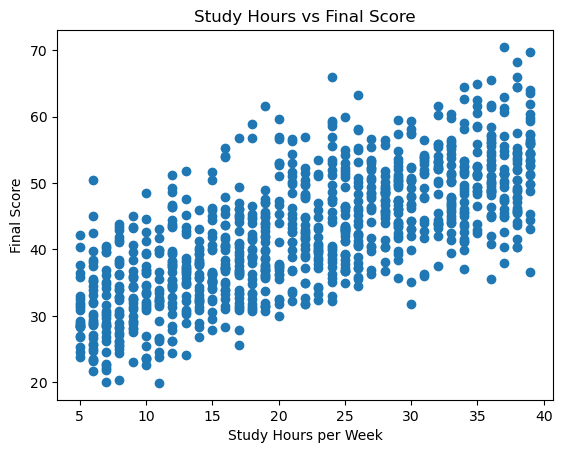

In [11]:
# =====================================================
# STEP 8: Visualization 1
# Scatter Plot: Study Hours vs Final Score
# helps understand relationship between study and performance
# =====================================================

plt.figure()

plt.scatter(df["Study_Hours_per_Week"], df["Final_Score"])

plt.title("Study Hours vs Final Score")

plt.xlabel("Study Hours per Week")

plt.ylabel("Final Score")

plt.show()



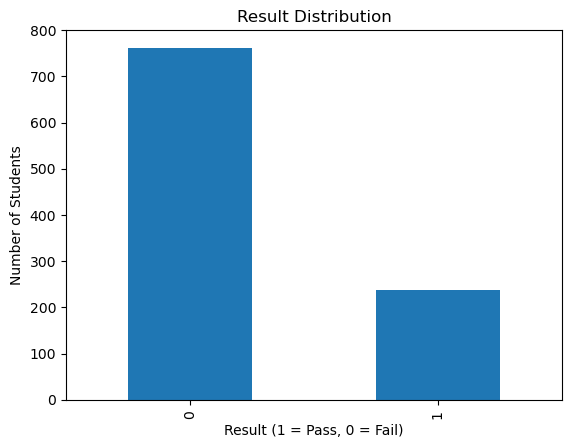

In [12]:
# =====================================================
# STEP 9: Visualization 2
# Bar Chart: Pass vs Fail distribution
# =====================================================

plt.figure()

df["Result"].value_counts().plot(kind="bar")

plt.title("Result Distribution")

plt.xlabel("Result (1 = Pass, 0 = Fail)")

plt.ylabel("Number of Students")

plt.show()



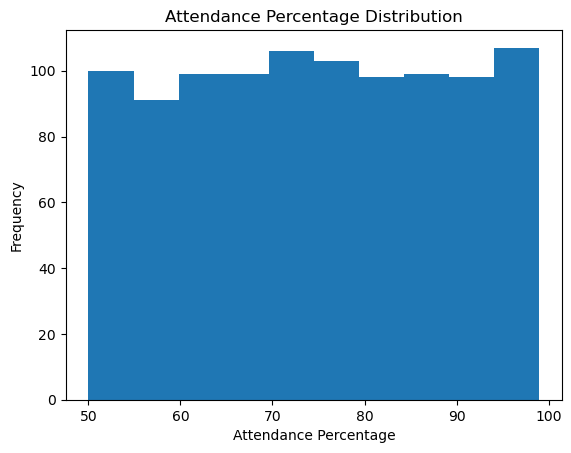

In [13]:
# =====================================================
# STEP 10: Visualization 3
# Histogram: Attendance Percentage Distribution
# =====================================================

plt.figure()

plt.hist(df["Attendance_Percentage"])

plt.title("Attendance Percentage Distribution")

plt.xlabel("Attendance Percentage")

plt.ylabel("Frequency")

plt.show()



In [14]:
# =====================================================
# STEP 11: Save Standardized Dataset
# save processed dataset for further analysis
# =====================================================

df.to_csv("standardized_student_dataset.csv", index=False)

print("\nStandardized dataset saved successfully.")


Standardized dataset saved successfully.
